# Change the rate of a target

The *rate* of a transient is its volumetric rate, in targets per Gpc³ per year. When you give a time range
(`tstart`/`tstop` or `nyears`) instead of a `size`, `skysurvey` uses it to decide how many targets to draw,
and it shapes their redshift distribution. This guide shows how to set a constant rate, a redshift-dependent rate,
and the Hubble constant the rate assumes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skysurvey
from skysurvey.survey import lsst

## Check the default rate

Each pre-defined transient comes with a default rate, stored in its `_RATE` class attribute.
For SNe Ia it is 2.35×10⁴ Gpc⁻³ yr⁻¹ (Perley et al. 2020):

In [2]:
snia = skysurvey.SNeIa()
snia.rate

23500.0

## Use a constant rate

Pass `rate=` to {meth}`~skysurvey.Target.from_draw` (or {meth}`~skysurvey.Target.draw`). Here we draw all SNe Ia
exploding over 10 days, full sky, up to z = 0.1, with a rate of 3×10⁴ Gpc⁻³ yr⁻¹. We do not give `size`:
the number of targets follows from the rate.

In [3]:
snia = skysurvey.SNeIa.from_draw(tstart=0, tstop=10, zmax=0.1, rate=3e4)
len(snia.data)

233

To change the rate of an existing instance, use {meth}`~skysurvey.Transient.set_rate`, then draw again.
Ten times the rate gives ten times more targets:

In [4]:
snia.set_rate(3e5)
_ = snia.draw(tstart=0, tstop=10, zmax=0.1, inplace=True)
len(snia.data)

2333

## Use a redshift-dependent rate

The rate can also be any function of redshift `z` returning the volumetric rate. For instance,
Frohmaier et al. (2019) measured the SN Ia rate as r(z) = r₀ (1 + z)^α with r₀ = 2.3×10⁴ Gpc⁻³ yr⁻¹ and α = 1.7:

In [5]:
def frohmaier_rate(z, r0=2.3e4, alpha=1.70):
    # SN Ia volumetric rate in targets/Gpc3/yr (Frohmaier et al. 2019)
    return r0 * (1 + z)**alpha

Let us draw the SNe Ia exploding during one year, up to z = 1, in a single LSST field
(the camera footprint, ~9.6 deg², see {func}`skysurvey.get_lsst_footprint`), with either the
constant default rate or the evolving one:

In [6]:
field = lsst.get_lsst_footprint()
options = dict(skyarea=field, zmin=0.01, zmax=1, tstart=0, tstop=365)

snia_const = skysurvey.SNeIa.from_draw(**options)
snia_evol = skysurvey.SNeIa.from_draw(rate=frohmaier_rate, **options)
print(f"constant rate: {len(snia_const.data)} SNe Ia | evolving rate: {len(snia_evol.data)} SNe Ia")

constant rate: 481 SNe Ia | evolving rate: 1143 SNe Ia


The evolving rate produces more targets at high redshift:

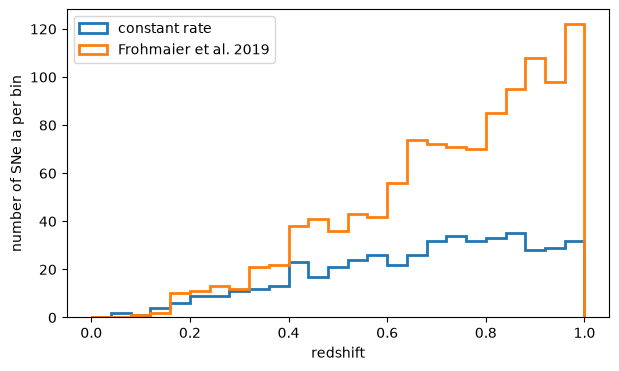

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, 1, 26)
ax.hist(snia_const.data["z"], bins=bins, histtype="step", lw=2, label="constant rate")
ax.hist(snia_evol.data["z"], bins=bins, histtype="step", lw=2, label="Frohmaier et al. 2019")
ax.set(xlabel="redshift", ylabel="number of SNe Ia per bin")
ax.legend();

## Set the Hubble constant assumed by the rate

Measured rates depend on the Hubble constant H₀ used to derive them. `skysurvey` assumes rates are given for
H₀ = 70 km/s/Mpc and rescales them by (H₀/70)³ to match the cosmology of the target (Planck18 by default).
If your rate was derived with another H₀, pass it with `rate_H0=` in `from_draw()` or `H0=` in `set_rate()`.
{meth}`~skysurvey.Transient.get_rate` returns the rate actually used (at z = 0, without time dilation):

In [8]:
snia = skysurvey.SNeIa()
print(f"target cosmology H0 = {snia.cosmology.H0:.2f}")

snia.set_rate(3e4)  # assumes H0 = 70 km/s/Mpc
print(f"rate given for H0=70:    {snia.get_rate(0):.0f} /Gpc3/yr")

snia.set_rate(3e4, H0=snia.cosmology.H0.value)  # rate derived with the same H0 as the cosmology
print(f"rate given for H0=67.66: {snia.get_rate(0):.0f} /Gpc3/yr")

target cosmology H0 = 67.66 km / (Mpc s)
rate given for H0=70:    27091 /Gpc3/yr
rate given for H0=67.66: 30000 /Gpc3/yr


:::{note}
To change the rate of a whole class rather than of one instance, set the `_RATE` attribute (and `_RATE_H0`
if needed) in a subclass, see [Create a transient class from your own templates](create_new_transient_class.ipynb).
:::

## Next steps

- [Draw a sample of targets](draw_and_from_draw.ipynb): `draw()` versus `from_draw()`.
- [Draw targets in a sky area](target_and_skyarea.ipynb): restrict the sky footprint of the simulation.
- [Change the model of a target](change_model_while_draw.ipynb): change how the target parameters are drawn.
- API: {meth}`skysurvey.Transient.set_rate`, {func}`skysurvey.target.rates.get_rate`.